# **Salmonid Mortality Data**
### Tidy Tuesday
*March 17, 2026*

### **Background**
The Norwegian Veterinary Institute has updated their annual *Fish Health Report*. This report centers around the health and welfare of farmed fish in Norway. Along with the Norwegian Food Safety Authority, these government agencies aim to lower fish mortality and to provide healthy fish for consumption. They are interested in how their current work has progressed since January 2020, with some guiding questions:
* How does monthly mortality differ across the time period data is available for?
* Which region has lowest mortality?
* What other types of loses may be significant in addition to death of fish?

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from pandasql import sqldf
import matplotlib.pyplot as plt

In [2]:
# Get data
monthly_losses_data = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-17/monthly_losses_data.csv')
monthly_mortality_data = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-17/monthly_mortality_data.csv')

### **Data Preview**
What information does the data tell?

In [3]:
monthly_losses_data

,species,date,geo_group,region,losses,dead,discarded,escaped,other
0,salmon,2020-01-01,area,1,31425,28126,3299,0,0
1,salmon,2020-01-01,area,2,324116,277888,46113,0,115
2,salmon,2020-01-01,area,3,844829,776983,63770,0,4076
3,salmon,2020-01-01,area,4,676852,623159,51823,0,1870
4,salmon,2020-01-01,area,5,109269,97627,11424,0,218
...,...,...,...,...,...,...,...,...,...
2803,rainbowtrout,2025-12-01,county,Møre og Romsdal,6597,6258,0,0,339
2804,rainbowtrout,2025-12-01,county,Trøndelag,292,283,0,0,9
2805,rainbowtrout,2025-12-01,county,Nordland,325,325,0,0,0
2806,rainbowtrout,2025-12-01,county,Troms,0,0,0,0,0


The above dataframe records the number of fish lost per day per region. It lists total losses, which is made up of dead fish, discarded fish (fish removed from the farm(s) due to disease/damage), escaped fish, and other losses.

In [4]:
monthly_mortality_data

,species,date,geo_group,region,median,q1,q3
0,rainbowtrout,2020-01-01,area,4,0.63,0.34,1.00
1,rainbowtrout,2020-02-01,area,4,0.60,0.41,1.17
2,rainbowtrout,2020-03-01,area,4,0.74,0.40,1.64
3,rainbowtrout,2020-04-01,area,4,0.51,0.19,1.59
4,rainbowtrout,2020-05-01,area,4,0.49,0.25,1.56
...,...,...,...,...,...,...,...
1783,salmon,2025-08-01,county,Finnmark,0.30,0.17,0.55
1784,salmon,2025-09-01,county,Finnmark,0.37,0.27,0.57
1785,salmon,2025-10-01,county,Finnmark,0.43,0.23,0.86
1786,salmon,2025-11-01,county,Finnmark,0.32,0.19,0.48


The above dataframe reports on the mortality rates per fish species in the regions.

### **Inspection**

In [5]:
print(monthly_losses_data.species.value_counts())
print()
print(monthly_mortality_data.species.value_counts())

species
salmon          1656
rainbowtrout    1152
Name: count, dtype: int64

species
salmon          1368
rainbowtrout     420
Name: count, dtype: int64


Both datasets have just the 2 species. I will now gather data specific to the two species.

In [6]:
# Subset by species
salmon = monthly_losses_data[monthly_losses_data['species']=='salmon'].reset_index().drop(['index'], axis=1)
rainbowtrout =  monthly_losses_data[monthly_losses_data['species']=='rainbowtrout'].reset_index().drop(['index'], axis=1)

In [7]:
# Get the total count of losses by category per species
def total_losses(df):
    # To record the final counts per month over time
    date = []
    losses = []
    dead = []
    discarded = []
    escaped = []
    other = []
    # Per each unique date
    for month in df.date.unique():
        # To record the sum of counts per each month
        mlosses = 0
        mdead = 0
        mdiscarded = 0
        mescaped = 0
        mother = 0
        for row in range(len(df)):
            # Check if date matches
            if df.loc[row]['date']==month:
                mlosses += df.loc[row]['losses']
                mdead += df.loc[row]['dead']
                mdiscarded += df.loc[row]['discarded']
                mescaped += df.loc[row]['escaped']
                mother += df.loc[row]['other']
        # Append the date and values
        date.append(month)
        losses.append(mlosses)
        dead.append(mdead)
        discarded.append(mdiscarded)
        escaped.append(mescaped)
        other.append(mother)
    # Return a new dataframe    
    loss_data = {
        'date':date,
        'losses': losses,
        'dead': dead,
        'discarded': discarded,
        'escaped': escaped,
        'other': other,
    }
    df2 = pd.DataFrame(loss_data)
    return df2

In [8]:
# Gather summed losses
salmon_losses = total_losses(salmon)
rainbowtrout_losses = total_losses(rainbowtrout)

#### *For easy reading*

In [9]:
# Above function can take a while to start...
# Export to csv for future analysis
salmon_losses.to_csv('salmon_losses.csv')
rainbowtrout_losses.to_csv('rainbowtrout_losses.csv')

In [10]:
# Read in the premade data
salmon_losses = pd.read_csv('salmon_losses.csv', index_col=0)
rainbowtrout_losses = pd.read_csv('rainbowtrout_losses.csv', index_col=0)
# Convert date columns to datetime format
salmon_losses['date'] = pd.to_datetime(salmon_losses['date'])
rainbowtrout_losses['date'] = pd.to_datetime(rainbowtrout_losses['date'])

**Salmon losses**

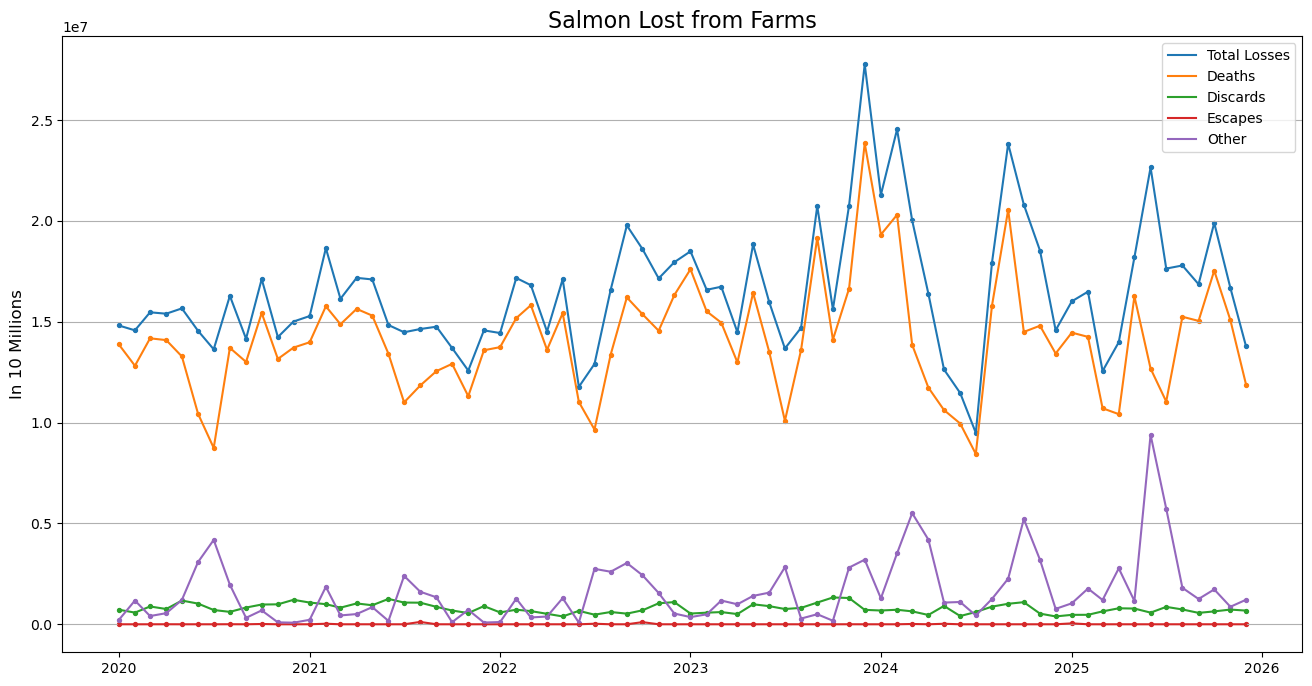

In [11]:
plt.figure(figsize=(16,8))
plt.scatter(salmon_losses.date, salmon_losses.losses, s=8)
plt.plot(salmon_losses.date, salmon_losses.losses, label='Total Losses')
plt.scatter(salmon_losses.date, salmon_losses.dead, s=8)
plt.plot(salmon_losses.date, salmon_losses.dead, label='Deaths')
plt.scatter(salmon_losses.date, salmon_losses.discarded, s=8)
plt.plot(salmon_losses.date, salmon_losses.discarded, label='Discards')
plt.scatter(salmon_losses.date, salmon_losses.escaped, s=8)
plt.plot(salmon_losses.date, salmon_losses.escaped, label='Escapes')
plt.scatter(salmon_losses.date, salmon_losses.other, s=8)
plt.plot(salmon_losses.date, salmon_losses.other, label='Other')
plt.legend()
plt.title('Salmon Lost from Farms', size=16)
plt.ylabel('In 10 Millions', size=12)
plt.grid(axis='y')
plt.show()

Deaths make up the bulk of salmon losses and corelates closely overall. Salmon that escape or are discarded from the farms follow a somewhat stable trend, but salmon that are removed for other reasons sporadically jump.

There is a sharp increase in salmon deaaths right around January 2024 followed by a decrease through the first half of that year before jumping up.

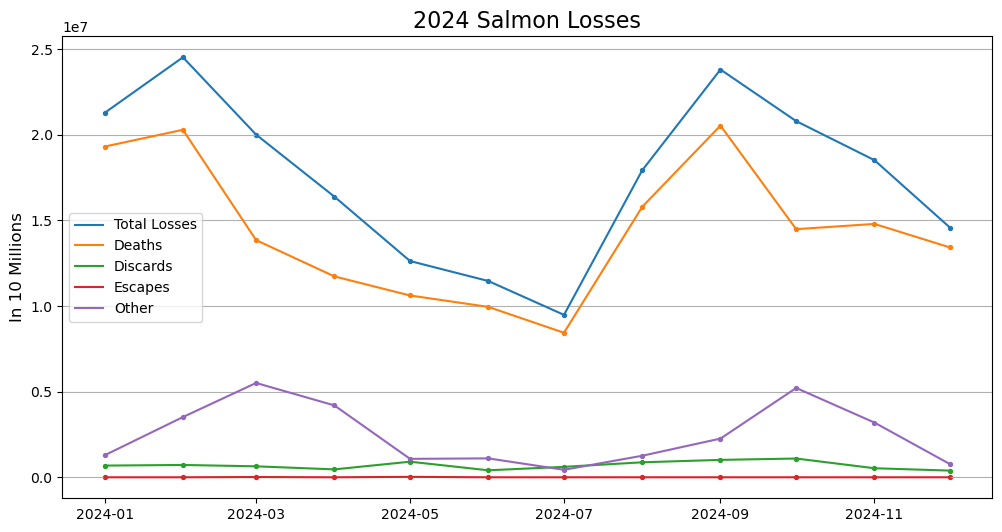

In [12]:
salmon_losses['year'] = salmon_losses['date'].dt.year # Get years
sl2024 = salmon_losses[salmon_losses['year']==2024] # Filter datat to 2024
# The plot
plt.figure(figsize=(12,6))
plt.scatter(sl2024.date, sl2024.losses, s=8)
plt.plot(sl2024.date, sl2024.losses, label='Total Losses')
plt.scatter(sl2024.date, sl2024.dead, s=8)
plt.plot(sl2024.date, sl2024.dead, label='Deaths')
plt.scatter(sl2024.date, sl2024.discarded, s=8)
plt.plot(sl2024.date, sl2024.discarded, label='Discards')
plt.scatter(sl2024.date, sl2024.escaped, s=8)
plt.plot(sl2024.date, sl2024.escaped, label='Escapes')
plt.scatter(sl2024.date, sl2024.other, s=8)
plt.plot(sl2024.date, sl2024.other, label='Other')
plt.legend()
plt.title('2024 Salmon Losses', size=16)
plt.ylabel('In 10 Millions', size=12)
plt.grid(axis='y')
plt.show()

The values display the raw total. We can use the mortality rates data to understand the porportional value of these totals.

In [13]:
# Formate data for Salmon mortality rates
salmon_mortality = monthly_mortality_data[monthly_mortality_data['species']=='salmon'].reset_index().drop(['index'], axis=1) # Filter salmon species
salmon_mortality['date'] = pd.to_datetime(salmon_mortality['date']) # Datetime column
salmon_mortality['month'] = salmon_mortality['date'].dt.month_name() # Extract month names
salmon_mortality['month_num'] = salmon_mortality['date'].dt.month # Extract month numbers for ordering puposes
salmon_mortality

,species,date,geo_group,region,median,q1,q3,month,month_num
0,salmon,2020-01-01,area,1 & 2,0.40,0.20,1.62,January,1
1,salmon,2020-02-01,area,1 & 2,0.51,0.21,1.08,February,2
2,salmon,2020-03-01,area,1 & 2,0.49,0.29,2.04,March,3
3,salmon,2020-04-01,area,1 & 2,0.41,0.27,1.04,April,4
4,salmon,2020-05-01,area,1 & 2,0.41,0.25,0.98,May,5
...,...,...,...,...,...,...,...,...,...
1363,salmon,2025-08-01,county,Finnmark,0.30,0.17,0.55,August,8
1364,salmon,2025-09-01,county,Finnmark,0.37,0.27,0.57,September,9
1365,salmon,2025-10-01,county,Finnmark,0.43,0.23,0.86,October,10
1366,salmon,2025-11-01,county,Finnmark,0.32,0.19,0.48,November,11


Months by lowest mortality rates.

In [14]:
sqldf('''
SELECT month, ROUND(AVG(median), 2) AS 'Average Mortality' FROM salmon_mortality
GROUP BY month
ORDER BY AVG(median) ASC
''')

,month,Average Mortality
0,July,0.43
1,June,0.45
2,August,0.53
3,November,0.57
4,September,0.59
5,May,0.59
6,October,0.59
7,December,0.67
8,April,0.69
9,February,0.73


In [15]:
months_salmon = sqldf('''
SELECT month, ROUND(AVG(median), 2) AS 'Average Mortality', month_num FROM salmon_mortality
GROUP BY month
ORDER BY month_num
''')

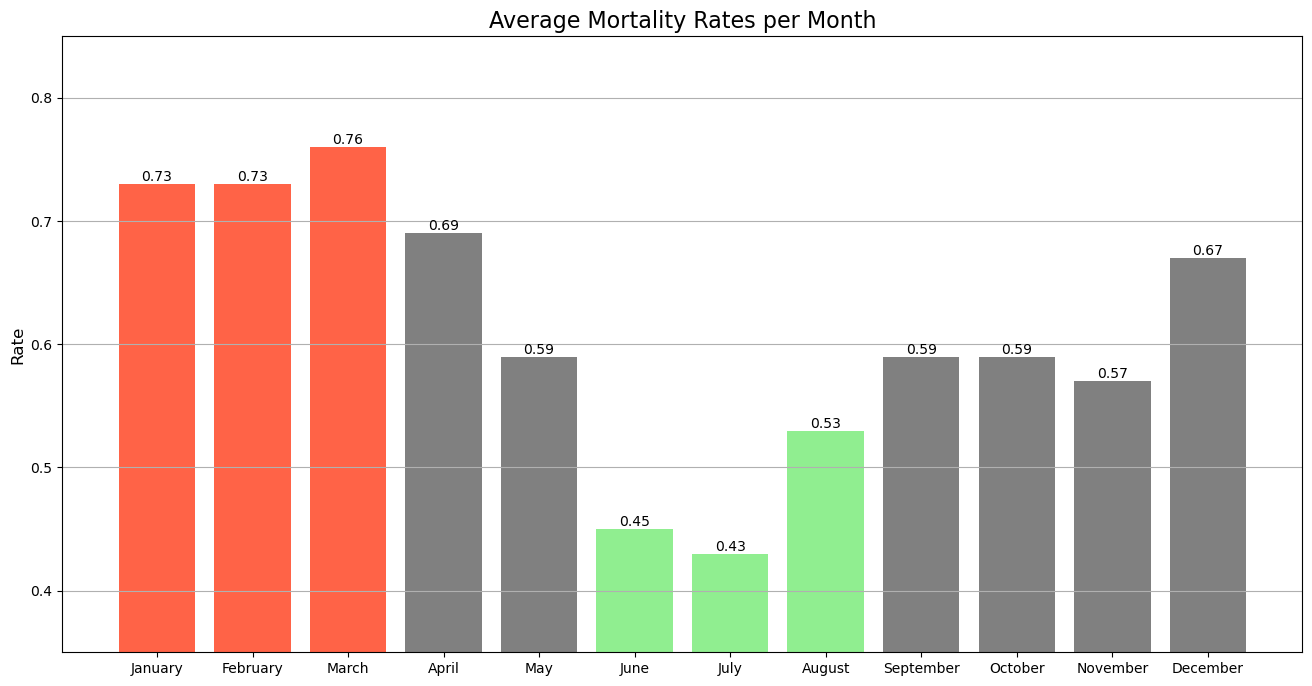

In [16]:
plt.figure(figsize=(16,8))
bars = plt.bar(months_salmon['month'], months_salmon['Average Mortality'], color='grey')
plt.bar(['June', 'July', 'August'], months_salmon['Average Mortality'][[5, 6, 7]], color='lightgreen')
plt.bar(['January', 'February', 'March'], months_salmon['Average Mortality'][[0, 1, 2]], color='tomato')
plt.bar_label(bars)
plt.ylim(0.35, 0.85)
plt.title('Average Mortality Rates per Month', size=16)
plt.ylabel('Rate', size=12)
plt.grid(axis='y')
plt.show()

The **summer months of July, June, and August fare the best** for salmon farms. The months closer to the beginning of a year (March, January, February) show higher mortality rates, which may have to do something with the colder temperatures affecting their habitats. Perhaps warmer months are better suited for salmon?

It may help to see if certain regions are doing better than others, as they may be doing something to keep better salmon numbers.

In [17]:
print('Top 5')
print(sqldf('''
SELECT region, ROUND(AVG(median), 2) AS 'Average Mortality' FROM salmon_mortality
GROUP BY region
ORDER BY AVG(median) ASC
LIMIT 5
'''))
print()
print('Bottom 5')
print(sqldf('''
SELECT region, ROUND(AVG(median), 2) AS 'Average Mortality' FROM salmon_mortality
GROUP BY region
ORDER BY AVG(median) DESC
LIMIT 5
'''))

Top 5
     region  Average Mortality
0         9               0.41
1  Nordland               0.43
2         8               0.46
3        11               0.47
4     Troms               0.49

Bottom 5
             region  Average Mortality
0                 3               0.82
1                 4               0.81
2          Vestland               0.80
3  Agder & Rogaland               0.72
4                 6               0.71


Regions with the lowest overall mortality rates are listed above. Regions with the highest rates are listed below.

### Conclusions
I was unable to complete the intended analysis. I did get some technical practise though.